<a href="https://colab.research.google.com/github/samyakobus/FYP2024/blob/main/Fold7_MFCC_URBAN8K_FINE_TUNE_EMBED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Getting the Urban8k Sound Dataset
======================================
Preprocessing

Using torchaudio.load() to return the signal and sample rate

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset
import torchaudio
import pandas as pd
import numpy as np

import os

import torch.nn.functional as F

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd  /content/drive/MyDrive/Colab_Notebooks/FYP /ECAPA_TDNN
!ls

/content/drive/MyDrive/Colab_Notebooks/FYP /ECAPA_TDNN
 dataLoader.py		       ECAPATDNNfold4_emb_10.pth   exps
 ECAPAModel.py		       ECAPATDNNfold4.pth	   FINE_TUNE
 ECAPA_TDNN_CLASSIFIER.ipynb   ECAPATDNNfold5_emb_10.pth   LOAD_DATA_ECAPA_TDNN_CLASSIFIER.ipynb
 ECAPATDNNfold10.pth	       ECAPATDNNfold5.pth	   loss.py
 ECAPATDNNfold1_emb_10.pth     ECAPATDNNfold6_emb_10.pth   model.py
 ECAPATDNNfold1.pth	       ECAPATDNNfold6.pth	   __pycache__
 ECAPATDNNfold2_emb_10.pth     ECAPATDNNfold7.pth	  'Quick Start Guide to Librosa.ipynb'
 ECAPATDNNfold2.pth	       ECAPATDNNfold8.pth	   tools.py
 ECAPATDNNfold3_emb_10.pth     ECAPATDNNfold9.pth	   trainECAPAModel.py
 ECAPATDNNfold3.pth	       ECAPATDNN.pth


UrbanSoundDataSet(Dataset) class
----------------------------------
Extracting MFCC
==============================
We will be extracting the Mel Coefficients for the Filter Bank, as the input of the ECAPA-TDNN are MFCCs, not the raw audio file waveforms.

We will be using TorchAudio to extract Mel Spectograms

Specifically, Transformations

Trying to use this notebook for MFCC transformations

https://github.com/mechanicalsea/spectra/blob/master/notebooks/Extracting%20MFCC%20by%20PyTorch-style%20Python.ipynb


<b>TORCHAUDIO.TRANSFORMS</b>

<br>To-do: preprocessing using CUDA</br>

In [ ]:
import torch
import torchaudio
import torchaudio.functional as AF
import math
import logging

import matplotlib.pyplot as plt

Shape of waveform: torch.Size([64000])
Sample rate of waveform: 16000


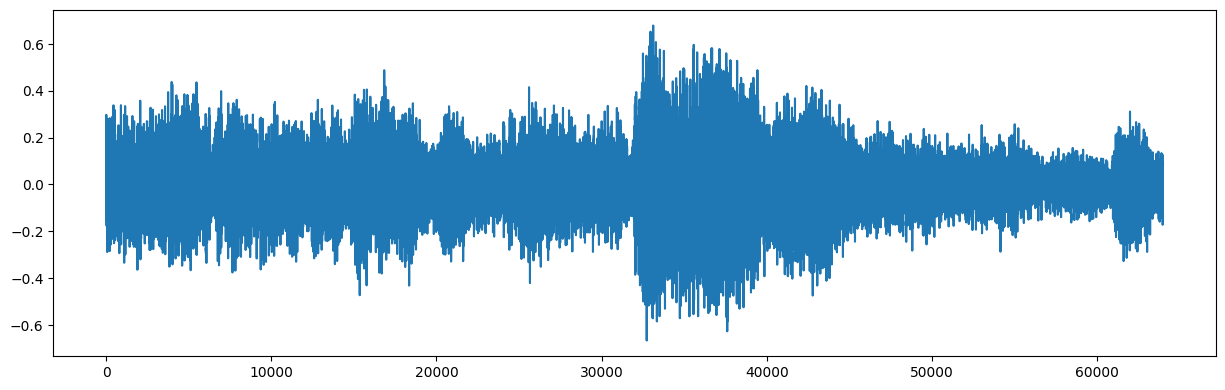

In [ ]:
wav_file = '/content/drive/MyDrive/Colab_Notebooks/FYP /AudioClassifier/UrbanSound8K/audio/fold1/108041-9-0-5.wav'
signal, samplerate = torchaudio.load(wav_file)
if signal.shape[0] > 1: #more than 1 channel
  signal = torch.mean(signal, dim=0, keepdim=True)
if samplerate != 16000:
      resampler = torchaudio.transforms.Resample(samplerate, 16000)
      signal = resampler(signal)
signal = signal[0]
samplerate = 16000
def wav_show(t, sr=None):
    print("Shape of waveform: {}".format(t.size()))
    if sr: print("Sample rate of waveform: {}".format(sr))
    plt.figure(figsize=(15, 4.5))
    plt.plot(t.numpy())
    plt.show()
def frame_show(t):
    print("Shape of spectrogram: {}".format(t.size()))
    plt.figure(figsize=(15, 4.5))
    plt.imshow(t.abs().numpy(), cmap='gray')
    plt.colorbar()
    plt.show()
wav_show(signal, samplerate)

In [ ]:
numcep = 80
nfilt = 26
nfft = 512
winlen = 0.025 #0.025 * 16000 = 400 samples for 16 kHz sampling rate
hoplen = 0.01 #0.01 * 16000 = 160 samples for 16kHz sampling rate

In [ ]:
def preemphasis(signal, preemph=0.97):
    """
    Pre-emphasis on the input signal
    :param signal: (time,)
    :param preemph:
    :return: (time,)
    """
    return torch.cat((signal[0:1], signal[1:] - preemph * signal[:-1]))

Shape of waveform: torch.Size([64000])
Sample rate of waveform: 16000


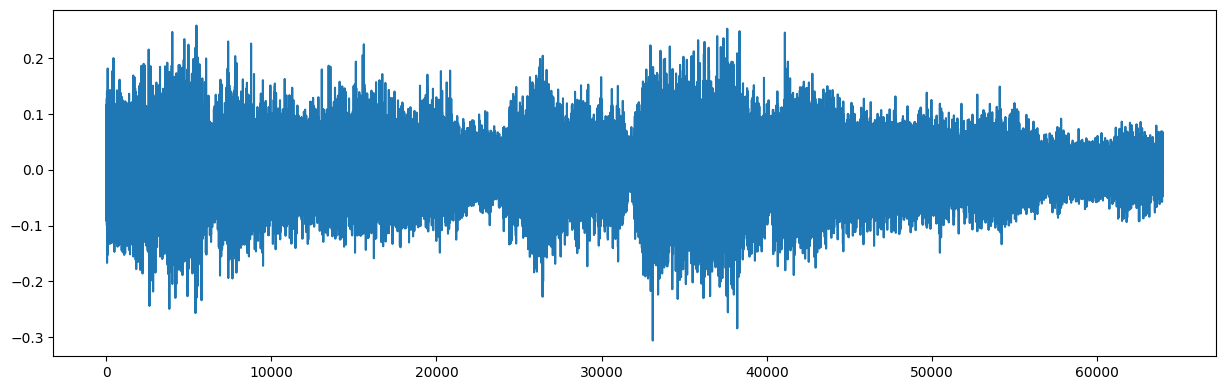

In [ ]:
samplerate = 16000
signal = preemphasis(signal, preemph=0.97)
wav_show(signal, samplerate)

In [ ]:
def framesig(signal, framelen, framehop, winfunc=lambda x: torch.ones((x,))):
    """
    Frame a signal into overlapping frames.
    :param signal: (time,)
    :param framelen:
    :param framehop:
    :param winfunc:
    :return: (nframes, framelen)
    """
    slen = len(signal)
    framelen = round(framelen)  # round_half_up(framelen)
    framehop = round(framehop)  # round_half_up(framehop)
    if slen <= framelen:
        nframes = 1
    else:
        nframes = 1 + int(math.ceil((1.0 * slen - framelen) / framehop))

    padlen = int((nframes - 1) * framehop + framelen)

    zeros = torch.zeros((padlen - slen,))
    padsignal = torch.cat((signal, zeros))

    indices = torch.arange(0, framelen).view((1, -1)) \
              + torch.arange(0, nframes * framehop, framehop).view((-1, 1))
    frames = padsignal[indices]
    win = winfunc(framelen).view((1, -1))
    return frames * win

In [ ]:
frames = framesig(signal, winlen*samplerate, hoplen*samplerate)
print('The length of a frame: {}, the length of a hop: {}'.format(round(winlen*samplerate),
                                                                  round(hoplen*samplerate)))
print(frames.shape)

The length of a frame: 400, the length of a hop: 160
torch.Size([399, 400])


In [ ]:
def magspec(frames, nfft):
    """
    Compute the magnitude spectrum of each frame.
    The result of `torch.rfft` is separate pairs of real and complex.
    :param frames: (nframes, framelen)
    :param nfft:
    :return: (nframes, nfft//2+1)
    """
    # if frames.shape[1] > nfft:
    #     logging.warning(
    #         'frame length (%d) is greater than FFT size (%d), frame will be truncated. Increase NFFT to avoid.',
    #         frames.shape[1], nfft)
    #     frames = frames[:, :nfft]
    # else:
    #     frames = torch.cat((frames, torch.zeros((frames.shape[0], nfft - frames.shape[1]))), 1)
    # complex_spec = torch.fft.rfft(frames, nfft)
    # print(complex_spec.shape)
    # #abs_spec = torch.sqrt(torch.sum(torch.mul(complex_spec,complex_spec),dim=2)) # complex absolute
    # return torch.norm(complex_spec, dim=1)
    """Compute the magnitude spectrum of each frame in frames. If frames is an NxD matrix, output will be Nx(NFFT/2+1).

    :param frames: the array of frames. Each row is a frame.
    :param NFFT: the FFT length to use. If NFFT > frame_len, the frames are zero-padded.
    :returns: If frames is an NxD matrix, output will be Nx(NFFT/2+1). Each row will be the magnitude spectrum of the corresponding frame.
    """
    if np.shape(frames)[1] > nfft:
        logging.warn(
            'frame length (%d) is greater than FFT size (%d), frame will be truncated. Increase NFFT to avoid.',
            np.shape(frames)[1], nfft)
    complex_spec = np.fft.rfft(frames, nfft)
    return np.absolute(complex_spec)


def powspec(frames, nfft):
    """
    Compute the power spectrum of each frame.
    :param frames: (nframes, framelen)
    :param nfft:
    :return: (nframes, nfft//2+1)
    """
    return 1.0 / nfft * (magspec(frames, nfft) ** 2)

pspec = powspec(frames, nfft)

print(pspec.shape)
pspec = torch.from_numpy(pspec)
pspec

(399, 257)


tensor([[4.0743e-06, 2.5810e-05, 1.8328e-05,  ..., 2.8157e-05, 4.7792e-05,
         2.3287e-04],
        [6.3948e-05, 6.9129e-05, 2.3545e-05,  ..., 2.2070e-05, 9.0050e-06,
         2.7260e-05],
        [2.4712e-05, 7.0052e-05, 6.5681e-06,  ..., 1.0413e-04, 3.0912e-05,
         5.3874e-06],
        ...,
        [7.2137e-06, 7.1176e-06, 2.8725e-06,  ..., 1.4222e-05, 1.3784e-06,
         7.2906e-06],
        [5.3665e-06, 3.1893e-05, 8.6446e-05,  ..., 1.4997e-05, 5.9303e-06,
         1.5687e-05],
        [1.4626e-05, 1.0720e-05, 8.3545e-06,  ..., 1.5613e-05, 9.4357e-06,
         2.8853e-05]], dtype=torch.float64)

Shape of spectrogram: torch.Size([257, 399])


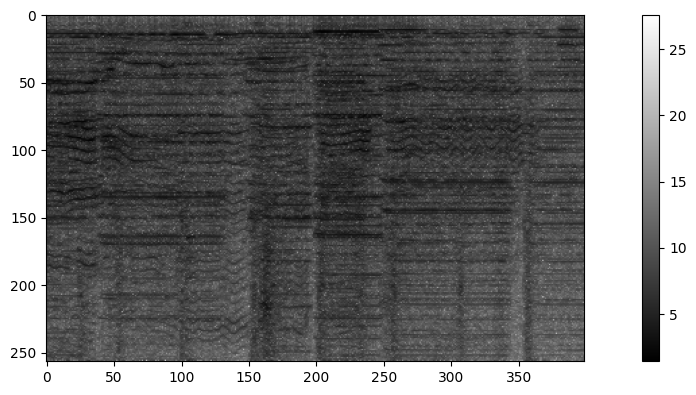

In [ ]:
pspec = powspec(frames, nfft)
pspec = torch.from_numpy(pspec)
frame_show(pspec.log().t())

In [ ]:
def get_energy(psepc):
    energy = torch.sum(pspec, 1)
    energy[energy == 0] = 2.220446049250313e-16
    return energy

Shape of waveform: torch.Size([399])


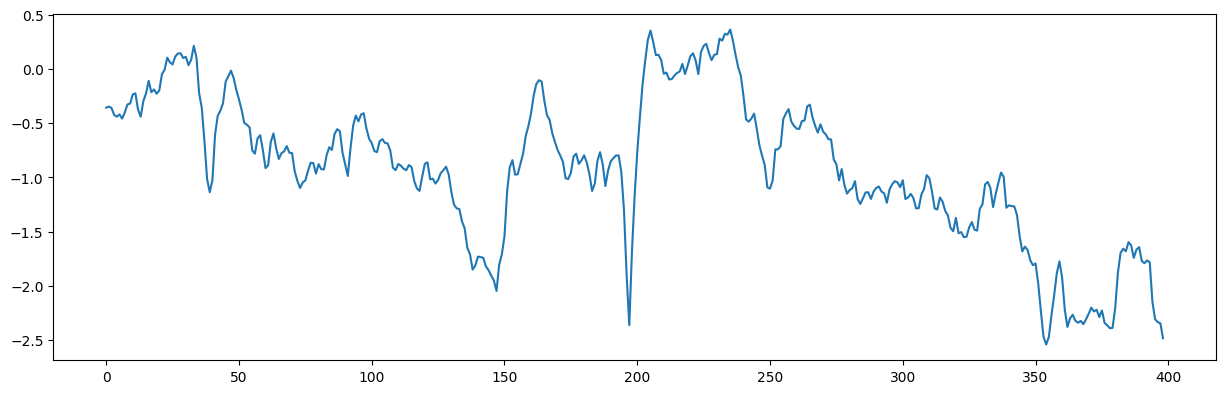

In [ ]:
energy = get_energy(pspec)
wav_show(energy.log())

In [ ]:
def hz2mel(hz):
    """
    Convert a value in Hertz(Hz) to Mels
    :param hz: float
    :return: float
    """
    return 2595 * math.log10(1 + hz / 700.)


def mel2hz(mel):
    """
    Convert a value in Mels to Hertz(Hz).
    :param mel: float
    :return: float
    """
    return 700 * (10 ** (mel / 2595.) - 1)


def get_filterbanks(nfilt=26, nfft=512, samplerate=16000, lowfreq=0, highfreq=None):
    """
    Create a matrix of Mel-filterbank.
    :param nfilt:
    :param nfft:
    :param samplerate:
    :param lowfreq:
    :param highfreq:
    :return: (nfilt, nfft//2+1)
    """
    highfreq = highfreq or samplerate >> 1
    assert highfreq <= samplerate / 2, "highfreq is greater than samplerate/2"

    lowmel = hz2mel(lowfreq)
    highmel = hz2mel(highfreq)
    melpoints = torch.linspace(lowmel, highmel, nfilt + 2)
    bin = torch.floor((nfft + 1) * mel2hz(melpoints) / samplerate)

    fbank = torch.zeros((nfilt, (nfft >> 1) + 1))
    for j in range(0, nfilt):
        for i in range(int(bin[j]), int(bin[j + 1])):
            fbank[j, i] = (i - bin[j]) / (bin[j + 1] - bin[j])
        for i in range(int(bin[j + 1]), int(bin[j + 2])):
            fbank[j, i] = (bin[j + 2] - i) / (bin[j + 2] - bin[j + 1])
    return fbank  # size (nfilt, nfft//2+1)


def melfilterbank(pspec, samplerate=16000, nfilt=26, nfft=512, lowfreq=0, highfreq=None):
    """
    Compute Mel-filterbank energy features from an audio signal.
    :param signal: (time,)
    :param samplerate:
    :param winlen:
    :param hoplen:
    :param nfilt: The number of filters in the filterbank.
    :param nfft:
    :param lowfreq:
    :param highfreq:
    :param preemph:
    :param winfunc:
    :return: (nframes, nfilt), (frames,)
    """
    highfreq = highfreq or samplerate >> 1
    fb = get_filterbanks(nfilt, nfft, samplerate, lowfreq, highfreq)
    fb = fb.double()
    feat = torch.mm(pspec, fb.T)
    feat[feat == 0] = 2.220446049250313e-16  # 极小正数替换0
    return torch.log(feat)  # feat: size (nframes, nfilt)

fb = get_filterbanks(nfilt, nfft, samplerate, 0, None)
fb

tensor([[0.0000, 0.5000, 1.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0800, 0.0400, 0.0000]])

Shape of spectrogram: torch.Size([26, 399])


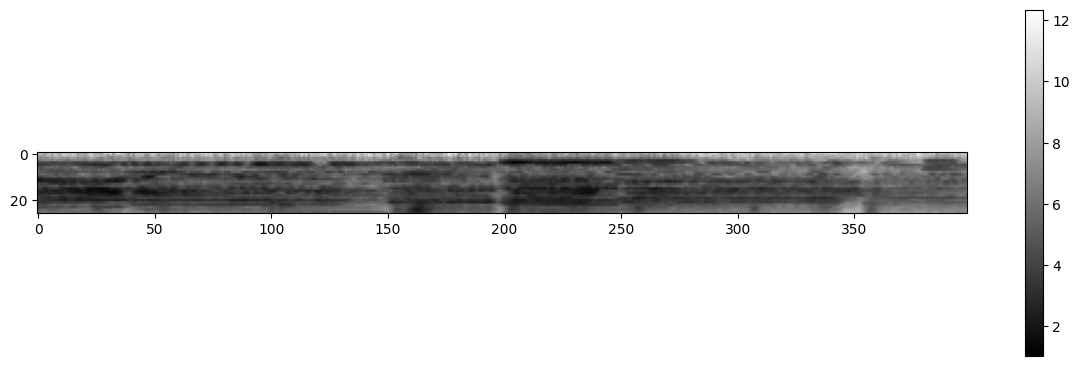

In [ ]:
feat = melfilterbank(pspec, nfilt=nfilt, nfft=nfft)
frame_show(feat.t())

In [ ]:
def lifter(cepstra, ceplifter=22):
    """
    Apply a cepstral lifter to the matrix of cepstra.
    :param cepstra: (nframes, numcep)
    :param ceplifter:
    :return: (nframes, numcep)
    """
    if ceplifter > 0:
        nframes, numcep = cepstra.shape
        lift = 1 + (ceplifter / 2.) * torch.sin(math.pi * torch.arange(numcep) / ceplifter)
        return lift * cepstra
    else:
        return cepstra

def mfcc_custom(feat, energy, numcep=80, nfilt=26, nfft=None, ceplifter=22, plusEnergy=True):
    """
    Compute MFCC from an audio signal.
    """
    feat = feat.mm(AF.create_dct(numcep, nfilt, norm='ortho').double())
    feat = lifter(feat, ceplifter)
    if plusEnergy: feat[:, 0] = torch.log(energy)
    return feat

Shape of spectrogram: torch.Size([80, 399])


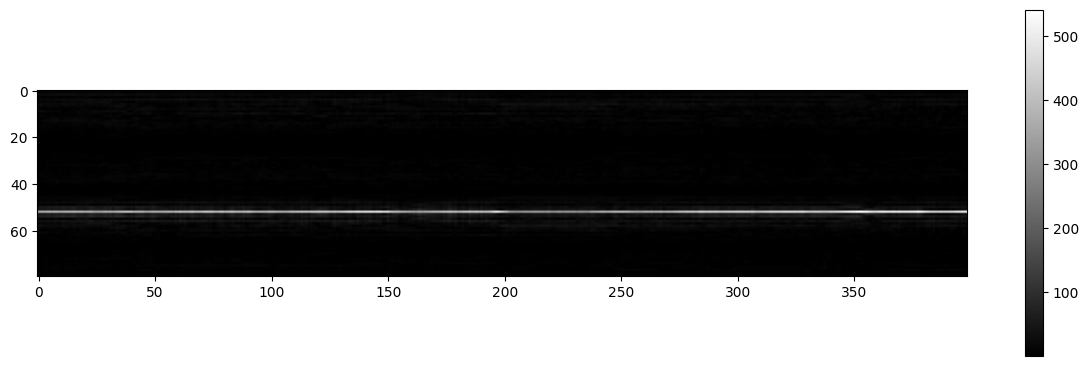

In [ ]:
mfcc_feat = mfcc_custom(feat, energy, numcep=numcep, nfilt=nfilt)
frame_show(mfcc_feat.t()) #maybe rename is better

In [ ]:
print(feat.shape)
print(feat)

torch.Size([399, 26])
tensor([[ -9.7703,  -7.9789,  -6.9387,  ...,  -3.9181,  -4.8016,  -5.4208],
        [ -9.5998,  -8.3833,  -6.8560,  ...,  -4.1073,  -5.2206,  -5.8332],
        [ -9.5895,  -7.9867,  -7.3981,  ...,  -4.0792,  -5.5455,  -6.0636],
        ...,
        [-10.7326,  -9.3445,  -8.1843,  ...,  -6.3785,  -6.9675,  -6.8808],
        [ -8.7965,  -9.6229,  -8.1985,  ...,  -6.4884,  -6.9132,  -7.0841],
        [-10.4927,  -9.1824,  -8.7439,  ...,  -6.6673,  -6.9762,  -7.2775]],
       dtype=torch.float64)


In [ ]:
class UrbanSoundDataset(Dataset):

  def __init__(self, annotations_file, audio_dir, transformation, target_sample_rate, num_samples, device):#transformation can be vague, as it can be mel, mfcc, etc.
    self.annotations = pd.read_csv(annotations_file)
    self.audio_dir = audio_dir
    self.device = device
    self.transformation = transformation
    self.target_sample_rate = target_sample_rate
    self.num_samples = num_samples

  def __len__(self):
    return len(self.annotations)


  def __getitem__(self, index): #enables the indexing from the Urban8k dataset
    numcep = 80
    nfilt = 26
    nfft = 512
    winlen = 0.025
    hoplen = 0.01
    audio_sample_path = self._get_audio_sample_path(index)
    label = self._get_audio_sample_label(index)
    signal, sr = torchaudio.load(audio_sample_path) #sr = sample rate
    #signal = signal.to(self.device)
    #signal -> (num_channels, samples) -> (2, 16000) -> a tensor with number of channels and samples

    # if signal.shape[0] > 1: #more than 1 channel
    #   signal = torch.mean(signal, dim=0, keepdim=True)
    # if samplerate != 16000:
    #       resampler = torchaudio.transforms.Resample(samplerate, 16000)
    #       signal = resampler(signal)
    # signal = signal[0]
    # samplerate = 16000

    #not all samples in Urban8k has the sample rate, so we need to sample it to uniform
    signal = self._resample_if_necessary(signal, sr) #resampling
    signal = self._mix_down_if_necessary(signal) #make it to mono
    signal = self._cut_if_necessary(signal)
    signal = self._right_pad_if_necessary(signal)
    #signal = self.transformation(signal)

    signal = signal[0]
    signal = preemphasis(signal, preemph=0.97)
    frames = framesig(signal, winlen*samplerate, hoplen*samplerate)
    pspec = powspec(frames, nfft)
    pspec = torch.from_numpy(pspec)
    energy = get_energy(pspec)
    feature = melfilterbank(pspec, nfilt=nfilt, nfft=nfft)
    feature_mfcc = mfcc_custom(feature, energy, numcep=80, nfilt=nfilt)
    feature_mfcc = feature_mfcc.to(torch.float32)

    return feature_mfcc, label


  def _cut_if_necessary(self, signal):
    # signal -> Tensor -> (1, n)
    if signal.shape[1] > self.num_samples:
      signal = signal[:, :self.num_samples]
    return signal

  def _right_pad_if_necessary(self, signal):
    length_signal = signal.shape[1]
    if length_signal < self.num_samples:
      num_missing_samples = self.num_samples - length_signal
      last_dim_padding = (0, num_missing_samples)  #(left pad, right pad)
      signal = torch.nn.functional.pad(signal, last_dim_padding)
    return signal


  def _resample_if_necessary(self, signal, sr):
    if sr != self.target_sample_rate:
      resampler = torchaudio.transforms.Resample(sr, self.target_sample_rate)
      signal = resampler(signal)
    return signal

  def _mix_down_if_necessary(self, signal): #aggregate multiple channels and make it to one channel -> use mean
    if signal.shape[0] > 1: #more than 1 channel
      signal = torch.mean(signal, dim=0, keepdim=True)
    return signal

  def _get_audio_sample_path(self, index):
    fold = f"fold{self.annotations.iloc[index, 5]}"
    path = os.path.join(self.audio_dir, fold, self.annotations.iloc[index, 0] )
    return path

  def _get_audio_sample_label(self, index):
    return self.annotations.iloc[index, 6]


if torch.cuda.is_available():
  device = "cuda"
else:
  device = "cpu"
print(f"Using device {device}")




Using device cuda


Apparently this is the Mel Spectogram, it is NOT the same as MFCCs, the Input to the ECAPA-TDNN is 80 Mel-Frequency Cepstral Coefficients

In [ ]:
ANNOTATIONS_FILE = "/content/drive/MyDrive/Colab_Notebooks/FYP /AudioClassifier/UrbanSound8K/metadata/UrbanSound8K.csv"
AUDIO_DIR = "/content/drive/MyDrive/Colab_Notebooks/FYP /AudioClassifier/UrbanSound8K/audio"
SAMPLE_RATE = 16000 #for ECAPA-TDNN is 16 kHz
NUM_SAMPLES = 64000

mel_spectogram = torchaudio.transforms.MelSpectrogram( #callable object
    sample_rate=SAMPLE_RATE,
    n_fft=512,
    win_length=400,
    hop_length=160,
    f_min = 20,
    f_max = 7600,
    window_fn=torch.hamming_window,
    n_mels=80
)

mfcc_object = torchaudio.transforms.MFCC(
    sample_rate=SAMPLE_RATE,
    n_mfcc=80,
    dct_type=2,
    norm = 'ortho',
    log_mels = True,
)


usd = UrbanSoundDataset(ANNOTATIONS_FILE, AUDIO_DIR, mel_spectogram, SAMPLE_RATE, NUM_SAMPLES, device)

print(f"There are {len(usd)} samples in the dataset.")

feature, label = usd[1]


print(feature.shape)
print(label)


/usr/local/lib/python3.10/dist-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


There are 8732 samples in the dataset.
torch.Size([399, 80])
2


Try to use this: https://www.youtube.com/watch?v=WJI-17MNpdE Librosa transformation feature to obtain 80 MFCCs

In [ ]:
print(feature)

tensor([[-3.5821e-01, -1.2771e+01, -1.1031e+01,  ..., -1.1660e+00,
          8.7706e-04,  1.1121e+00],
        [-3.4717e-01, -1.0571e+01, -8.8942e+00,  ...,  8.6583e-01,
          8.8602e-04, -8.2929e-01],
        [-3.6045e-01, -1.0864e+01, -9.3409e+00,  ...,  6.1216e+00,
          9.0148e-04, -5.8508e+00],
        ...,
        [-2.3349e+00, -2.1365e+01, -2.1702e+01,  ..., -2.3085e+00,
          5.2381e-04,  2.2039e+00],
        [-2.3461e+00, -2.1040e+01, -2.3372e+01,  ..., -8.1227e-02,
          5.3694e-04,  7.5864e-02],
        [-2.4844e+00, -2.2185e+01, -2.3923e+01,  ..., -4.7825e-01,
          5.2802e-04,  4.5518e-01]])


# **ECAPA-TDNN Model**

Informal Implementation of ECAPA-TDNN:

https://github.com/lawlict/ECAPA-TDNN/tree/2bb4992685bfba73b7dab9f821b561742ff347a3

In [ ]:
!pip install torchsummary

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary


''' Res2Conv1d + BatchNorm1d + ReLU
'''
class Res2Conv1dReluBn(nn.Module):
    '''
    in_channels == out_channels == channels
    '''
    def __init__(self, channels, kernel_size=1, stride=1, padding=0, dilation=1, bias=False, scale=4):
        super().__init__()
        assert channels % scale == 0, "{} % {} != 0".format(channels, scale)
        self.scale = scale
        self.width = channels // scale
        self.nums = scale if scale == 1 else scale - 1

        self.convs = []
        self.bns = []
        for i in range(self.nums):
            self.convs.append(nn.Conv1d(self.width, self.width, kernel_size, stride, padding, dilation, bias=bias))
            self.bns.append(nn.BatchNorm1d(self.width))
        self.convs = nn.ModuleList(self.convs)
        self.bns = nn.ModuleList(self.bns)

    def forward(self, x):
        out = []
        spx = torch.split(x, self.width, 1)
        for i in range(self.nums):
            if i == 0:
                sp = spx[i]
            else:
                sp = sp + spx[i]
            # Order: conv -> relu -> bn
            sp = self.convs[i](sp)
            sp = self.bns[i](F.relu(sp))
            out.append(sp)
        if self.scale != 1:
            out.append(spx[self.nums])
        out = torch.cat(out, dim=1)
        return out



''' Conv1d + BatchNorm1d + ReLU
'''
class Conv1dReluBn(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=1, stride=1, padding=0, dilation=1, bias=False):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding, dilation, bias=bias)
        self.bn = nn.BatchNorm1d(out_channels)

    def forward(self, x):
        return self.bn(F.relu(self.conv(x)))



''' The SE connection of 1D case.
'''
class SE_Connect(nn.Module):
    def __init__(self, channels, s=2):
        super().__init__()
        assert channels % s == 0, "{} % {} != 0".format(channels, s)
        self.linear1 = nn.Linear(channels, channels // s)
        self.linear2 = nn.Linear(channels // s, channels)

    def forward(self, x):
        out = x.mean(dim=2)
        out = F.relu(self.linear1(out))
        out = torch.sigmoid(self.linear2(out))
        out = x * out.unsqueeze(2)
        return out



''' SE-Res2Block.
    Note: residual connection is implemented in the ECAPA_TDNN model, not here.
'''
def SE_Res2Block(channels, kernel_size, stride, padding, dilation, scale):
    return nn.Sequential(
        Conv1dReluBn(channels, channels, kernel_size=1, stride=1, padding=0),
        Res2Conv1dReluBn(channels, kernel_size, stride, padding, dilation, scale=scale),
        Conv1dReluBn(channels, channels, kernel_size=1, stride=1, padding=0),
        SE_Connect(channels)
    )



''' Attentive weighted mean and standard deviation pooling.
'''
class AttentiveStatsPool(nn.Module):
    def __init__(self, in_dim, bottleneck_dim):
        super().__init__()
        # Use Conv1d with stride == 1 rather than Linear, then we don't need to transpose inputs.
        self.linear1 = nn.Conv1d(in_dim, bottleneck_dim, kernel_size=1) # equals W and b in the paper
        self.linear2 = nn.Conv1d(bottleneck_dim, in_dim, kernel_size=1) # equals V and k in the paper

    def forward(self, x):
        # DON'T use ReLU here! In experiments, I find ReLU hard to converge.
        alpha = torch.tanh(self.linear1(x))
        alpha = torch.softmax(self.linear2(alpha), dim=2)
        mean = torch.sum(alpha * x, dim=2)
        residuals = torch.sum(alpha * x ** 2, dim=2) - mean ** 2
        std = torch.sqrt(residuals.clamp(min=1e-9))
        return torch.cat([mean, std], dim=1)



''' Implementation of
    "ECAPA-TDNN: Emphasized Channel Attention, Propagation and Aggregation in TDNN Based Speaker Verification".

    Note that we DON'T concatenate the last frame-wise layer with non-weighted mean and standard deviation,
    because it brings little improvment but significantly increases model parameters.
    As a result, this implementation basically equals the A.2 of Table 2 in the paper.
'''
class ECAPA_TDNN(nn.Module):
    def __init__(self, in_channels=80, channels=512, embd_dim=10):
        super().__init__()
        self.layer1 = Conv1dReluBn(in_channels, channels, kernel_size=5, padding=2)
        self.layer2 = SE_Res2Block(channels, kernel_size=3, stride=1, padding=2, dilation=2, scale=8)
        self.layer3 = SE_Res2Block(channels, kernel_size=3, stride=1, padding=3, dilation=3, scale=8)
        self.layer4 = SE_Res2Block(channels, kernel_size=3, stride=1, padding=4, dilation=4, scale=8)

        cat_channels = channels * 3
        self.conv = nn.Conv1d(cat_channels, 1536, kernel_size=1)
        self.pooling = AttentiveStatsPool(1536, 128)
        self.bn1 = nn.BatchNorm1d(3072)
        self.linear = nn.Linear(3072, embd_dim)
        self.bn2 = nn.BatchNorm1d(embd_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        out1 = self.layer1(x)
        out2 = self.layer2(out1) + out1
        out3 = self.layer3(out1 + out2) + out1 + out2
        out4 = self.layer4(out1 + out2 + out3) + out1 + out2 + out3

        out = torch.cat([out2, out3, out4], dim=1)
        out = F.relu(self.conv(out))
        out = self.bn1(self.pooling(out))
        out = self.bn2(self.linear(out))
        return out





In [ ]:
  # Input size: batch_size * seq_len * feat_dim
x = torch.zeros(2, 200, 80)
model = ECAPA_TDNN()
out = model(x)
out.to(device) #does not work with model(x)
print(model)
print(out.shape)    # should be [2, 192]


ECAPA_TDNN(
  (layer1): Conv1dReluBn(
    (conv): Conv1d(80, 512, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer2): Sequential(
    (0): Conv1dReluBn(
      (conv): Conv1d(512, 512, kernel_size=(1,), stride=(1,), bias=False)
      (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): Res2Conv1dReluBn(
      (convs): ModuleList(
        (0-6): 7 x Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,), bias=False)
      )
      (bns): ModuleList(
        (0-6): 7 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): Conv1dReluBn(
      (conv): Conv1d(512, 512, kernel_size=(1,), stride=(1,), bias=False)
      (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (3): SE_Connect(
      (linear1): Linear(in_features=512

In [ ]:
summary(model.cuda(),(399,80))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1             [-1, 512, 399]         204,800
       BatchNorm1d-2             [-1, 512, 399]           1,024
      Conv1dReluBn-3             [-1, 512, 399]               0
            Conv1d-4             [-1, 512, 399]         262,144
       BatchNorm1d-5             [-1, 512, 399]           1,024
      Conv1dReluBn-6             [-1, 512, 399]               0
            Conv1d-7              [-1, 64, 399]          12,288
       BatchNorm1d-8              [-1, 64, 399]             128
            Conv1d-9              [-1, 64, 399]          12,288
      BatchNorm1d-10              [-1, 64, 399]             128
           Conv1d-11              [-1, 64, 399]          12,288
      BatchNorm1d-12              [-1, 64, 399]             128
           Conv1d-13              [-1, 64, 399]          12,288
      BatchNorm1d-14              [-1, 

Training The Model
=======================
Training the ECAPA_TDNN Model
<br> using dataloader </br>

In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE = 256
EPOCHS = 10
LEARNING_RATE = 0.001

In [ ]:
def create_data_loader(train_data, batch_size):
    train_dataloader = DataLoader(train_data, batch_size=batch_size)
    return train_dataloader

def train_single_epoch(model, data_loader, loss_fn, optimiser, device):
    for input, target in data_loader:
        input, target = input.to(device), target.to(device)

        # calculate loss
        prediction = model(input)
        loss = loss_fn(prediction, target)

        # backpropagate error and update weights
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

    print(f"loss: {loss.item()}")


def train(model, data_loader, loss_fn, optimiser, device, epochs):
    for i in range(epochs):
        print(f"Epoch {i+1}")
        train_single_epoch(model, data_loader, loss_fn, optimiser, device)
        print("---------------------------")
    print("Finished training")

In [ ]:
#instantiating our dataset Urban 8k dataset

if torch.cuda.is_available():
  device = "cuda"
else:
  device = "cpu"
print(f"Using {device}")

Using cuda


In [ ]:
mel_spectogram = torchaudio.transforms.MelSpectrogram( #callable object
    sample_rate=SAMPLE_RATE,
    n_fft=512,
    win_length=400,
    hop_length=160,
    f_min = 20,
    f_max = 7600,
    window_fn=torch.hamming_window,
    n_mels=80
)

mfcc = torchaudio.transforms.MFCC(
    sample_rate=SAMPLE_RATE,
    n_mfcc=80,
    dct_type=2,
    norm = 'ortho',
    log_mels = True,
    melkwargs={"n_fft": 512, "hop_length": 160, "n_mels": 80, "center": False, "win_length":400, "f_min":20, "f_max":7600,  "window_fn": torch.hamming_window},
)


usd = UrbanSoundDataset(ANNOTATIONS_FILE,
                        AUDIO_DIR,
                        mfcc,
                        SAMPLE_RATE,
                        NUM_SAMPLES,
                        device)

sample, sr = usd[1]
print(sample.shape)

torch.Size([399, 80])


In [ ]:

#construct model and assign it to device
train_dataloader = create_data_loader(usd, BATCH_SIZE)
train_dataloader = train_dataloader
feed_forward_net = model.to(device)
print(feed_forward_net)

#initialise loss funciton + optimiser
loss_fn = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(feed_forward_net.parameters(),
                             lr=LEARNING_RATE)


ECAPA_TDNN(
  (layer1): Conv1dReluBn(
    (conv): Conv1d(80, 512, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer2): Sequential(
    (0): Conv1dReluBn(
      (conv): Conv1d(512, 512, kernel_size=(1,), stride=(1,), bias=False)
      (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): Res2Conv1dReluBn(
      (convs): ModuleList(
        (0-6): 7 x Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,), bias=False)
      )
      (bns): ModuleList(
        (0-6): 7 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): Conv1dReluBn(
      (conv): Conv1d(512, 512, kernel_size=(1,), stride=(1,), bias=False)
      (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (3): SE_Connect(
      (linear1): Linear(in_features=512

In [ ]:
# #train model
# train(feed_forward_net, train_dataloader, loss_fn, optimiser, device, EPOCHS)

# #save model
# torch.save(feed_forward_net.state_dict(), "ECAPATDNN.pth")
# print("Trained ECAPA-TDNN Model on Urban8k saved at ECAPATDNN.pth")

# **Evaluating the Model**

evaluate the trained ECAPA-TDNN model (ECAPA-TDNN.pth) trained with the Urban8k sound

In [ ]:

class_mapping = [
    "air_conditioner",
    "car_horn",
    "children_playing",
    "dog_bark",
    "drilling",
    "engine_idling",
    "gun_shot",
    "jackhammer",
    "siren",
    "street_music"
]


def predict(model, input, target, class_mapping):
    model.eval()
    with torch.no_grad():
        predictions = model(input)
        # Tensor (1, 10) -> [ [0.1, 0.01, ..., 0.6] ]
        predicted_index = predictions[0].argmax(0)
        predicted = class_mapping[predicted_index]
        expected = class_mapping[target]
    return predicted, expected


In [ ]:
ecapa_tdnn = ECAPA_TDNN()
state_dict = torch.load("FINE_TUNE/ECAPATDNN_FINE_TUNE.pth")
ecapa_tdnn.load_state_dict(state_dict)

usd = UrbanSoundDataset(ANNOTATIONS_FILE,
                        AUDIO_DIR,
                        mfcc_custom,
                        SAMPLE_RATE,
                        NUM_SAMPLES,
                        "cpu")

# get a sample from the urban sound dataset for inference
input, target = usd[6513][0], usd[6513][1] # [batch size, num_channels, fr, time]
input.unsqueeze_(0)
#6513 has different results
# make an inference
predicted, expected = predict(ecapa_tdnn, input, target,
                                  class_mapping)
print(f"Predicted: '{predicted}', expected: '{expected}'")

Predicted: 'jackhammer', expected: 'drilling'


Try to make a 10-fold evaluation for Urban8K dataset



In [ ]:
def test(model, epoch):
    model.eval()
    correct = 0
    for data, target in test_loader:
        data = data.to(device)
        target = target.to(device)
        output = model(data)
        output = output.permute(1, 0, 2)
        pred = output.max(2)[1] # get the index of the max log-probability
        correct += pred.eq(target).cpu().sum().item()
    print('\nTest set: Accuracy: {}/{} ({:.0f}%)\n'.format(
        correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

making a test set from fold:10

In [ ]:
AUDIO_DIR = "/content/drive/MyDrive/Colab_Notebooks/FYP /AudioClassifier/UrbanSound8K/audio/"
class getTestSet(Dataset):

  def __init__(self, annotations_file, audio_dir, transformation, target_sample_rate, num_samples, device, folderList):#transformation can be vague, as it can be mel, mfcc, etc.
    self.annotations = pd.read_csv(annotations_file)
    self.audio_dir = audio_dir
    self.device = device
    self.transformation = transformation
    self.target_sample_rate = target_sample_rate
    self.num_samples = num_samples

    #initialize lists to hold file names, labels, and folder numbers
    self.file_names = []
    self.labels = []
    self.folders = []

    for i in range(0,len(self.annotations)):
      if self.annotations.iloc[i, 5] in folderList:
        self.file_names.append(self.annotations.iloc[i, 0])
        self.labels.append(self.annotations.iloc[i, 6])
        self.folders.append(self.annotations.iloc[i, 5])

    self.file_path = audio_dir
    self.folderList = folderList


  def __len__(self):
    return len(self.file_names)


  def __getitem__(self, index): #enables the indexing from the Urban8k dataset
    numcep = 80
    nfilt = 26
    nfft = 512
    winlen = 0.025
    hoplen = 0.01
    path = self.file_path + "fold" + str(self.folders[index]) + "/" + self.file_names[index]
    signal, sr = torchaudio.load(path) #sr = sample rate

    #not all samples in Urban8k has the sample rate, so we need to sample it to uniform
    signal = self._resample_if_necessary(signal, sr) #resampling
    signal = self._mix_down_if_necessary(signal) #make it to mono
    signal = self._cut_if_necessary(signal)
    signal = self._right_pad_if_necessary(signal)
    signal = signal[0]
    signal = preemphasis(signal, preemph=0.97)
    frames = framesig(signal, winlen*samplerate, hoplen*samplerate)
    pspec = powspec(frames, nfft)
    pspec = torch.from_numpy(pspec)
    energy = get_energy(pspec)
    feature = melfilterbank(pspec, nfilt=nfilt, nfft=nfft)
    feature_mfcc = mfcc_custom(feature, energy, numcep=80, nfilt=nfilt)
    feature_mfcc = feature_mfcc.to(torch.float32)

    return feature_mfcc, self.labels[index]


  def _cut_if_necessary(self, signal):
    # signal -> Tensor -> (1, n)
    if signal.shape[1] > self.num_samples:
      signal = signal[:, :self.num_samples]
    return signal

  def _right_pad_if_necessary(self, signal):
    length_signal = signal.shape[1]
    if length_signal < self.num_samples:
      num_missing_samples = self.num_samples - length_signal
      last_dim_padding = (0, num_missing_samples)  #(left pad, right pad)
      signal = torch.nn.functional.pad(signal, last_dim_padding)
    return signal


  def _resample_if_necessary(self, signal, sr):
    if sr != self.target_sample_rate:
      resampler = torchaudio.transforms.Resample(sr, self.target_sample_rate)
      signal = resampler(signal)
    return signal

  def _mix_down_if_necessary(self, signal): #aggregate multiple channels and make it to one channel -> use mean
    if signal.shape[0] > 1: #more than 1 channel
      signal = torch.mean(signal, dim=0, keepdim=True)
    return signal

  def _get_audio_sample_label(self, index):
    return self.annotations.iloc[index, 6]


if torch.cuda.is_available():
  device = "cuda"
else:
  device = "cpu"
print(f"Using device {device}")



Using device cuda


In [ ]:
test_set = getTestSet(ANNOTATIONS_FILE, AUDIO_DIR, mel_spectogram, SAMPLE_RATE, NUM_SAMPLES, device, [10])
testFeature, testLabel = test_set[1]
testLabel

1

In [ ]:
print("Test Set Size is: " + str(len(test_set)))

Test Set Size is: 837


In [ ]:
test_loader = torch.utils.data.DataLoader(test_set, batch_size = 256)

In [ ]:
ecapa_tdnn = ECAPA_TDNN()
state_dict = torch.load("FINE_TUNE/ECAPATDNN_FINE_TUNE.pth")
ecapa_tdnn.load_state_dict(state_dict)

# get a sample from the urban sound dataset for inference
input, target = test_set[400][0], test_set[400][1] # [batch size, num_channels, fr, time]
input.unsqueeze_(0)
#6513 has different results
# make an inference
predicted, expected = predict(ecapa_tdnn, input, target,
                                  class_mapping)
print(f"Predicted: '{predicted}', expected: '{expected}'")

Predicted: 'jackhammer', expected: 'drilling'


In [ ]:
def test(model, test_set):
  class_mapping = [
    "air_conditioner",
    "car_horn",
    "children_playing",
    "dog_bark",
    "drilling",
    "engine_idling",
    "gun_shot",
    "jackhammer",
    "siren",
    "street_music"
  ]
  model.to(device)
  correct = 0
  model.eval()
  for i in range(len(test_set)):
      input, target = usd[i][0], usd[i][1]
      input.unsqueeze_(0)
      input = input.to(device)
      output = model(input)
      with torch.no_grad():
        predictions = model(input)
        # Tensor (1, 10) -> [ [0.1, 0.01, ..., 0.6] ]
        predicted_index = predictions[0].argmax(0)
        predicted_index = int(predicted_index)
        if (predicted_index == target):
          correct += 1


      if (int(len(test_set)/10) % int(i+1) == 0):
        print("Progress " + str((i+1)/len(test_set)) + "%")
  print('\nTest set: Accuracy: {}/{} ({:.0f}%)\n'.format(
        correct, len(test_set),
        100. * correct / len(test_set)))


In [ ]:
# test(ecapa_tdnn, test_set)

making a training set: 9 folders

In [ ]:
class getTrainSet(Dataset):

  def __init__(self, annotations_file, audio_dir, transformation, target_sample_rate, num_samples, device, folderList):#transformation can be vague, as it can be mel, mfcc, etc.
    self.annotations = pd.read_csv(annotations_file)
    self.audio_dir = audio_dir
    self.device = device
    self.transformation = transformation
    self.target_sample_rate = target_sample_rate
    self.num_samples = num_samples

    #initialize lists to hold file names, labels, and folder numbers
    self.file_names = []
    self.labels = []
    self.folders = []

    for i in range(0,len(self.annotations)):
      if self.annotations.iloc[i, 5] in folderList:
        self.file_names.append(self.annotations.iloc[i, 0])
        self.labels.append(self.annotations.iloc[i, 6])
        self.folders.append(self.annotations.iloc[i, 5])

    self.file_path = audio_dir
    self.folderList = folderList


  def __len__(self):
    return len(self.file_names)


  def __getitem__(self, index): #enables the indexing from the Urban8k dataset
    numcep = 80
    nfilt = 26
    nfft = 512
    winlen = 0.025
    hoplen = 0.01
    path = self.file_path + "fold" + str(self.folders[index]) + "/" + self.file_names[index]
    signal, sr = torchaudio.load(path) #sr = sample rate

    #not all samples in Urban8k has the sample rate, so we need to sample it to uniform
    signal = self._resample_if_necessary(signal, sr) #resampling
    signal = self._mix_down_if_necessary(signal) #make it to mono
    signal = self._cut_if_necessary(signal)
    signal = self._right_pad_if_necessary(signal)
    signal = signal[0]
    signal = preemphasis(signal, preemph=0.97)
    frames = framesig(signal, winlen*samplerate, hoplen*samplerate)
    pspec = powspec(frames, nfft)
    pspec = torch.from_numpy(pspec)
    energy = get_energy(pspec)
    feature = melfilterbank(pspec, nfilt=nfilt, nfft=nfft)
    feature_mfcc = mfcc_custom(feature, energy, numcep=80, nfilt=nfilt)
    feature_mfcc = feature_mfcc.to(torch.float32)

    return feature_mfcc, self.labels[index]


  def _cut_if_necessary(self, signal):
    # signal -> Tensor -> (1, n)
    if signal.shape[1] > self.num_samples:
      signal = signal[:, :self.num_samples]
    return signal

  def _right_pad_if_necessary(self, signal):
    length_signal = signal.shape[1]
    if length_signal < self.num_samples:
      num_missing_samples = self.num_samples - length_signal
      last_dim_padding = (0, num_missing_samples)  #(left pad, right pad)
      signal = torch.nn.functional.pad(signal, last_dim_padding)
    return signal


  def _resample_if_necessary(self, signal, sr):
    if sr != self.target_sample_rate:
      resampler = torchaudio.transforms.Resample(sr, self.target_sample_rate)
      signal = resampler(signal)
    return signal

  def _mix_down_if_necessary(self, signal): #aggregate multiple channels and make it to one channel -> use mean
    if signal.shape[0] > 1: #more than 1 channel
      signal = torch.mean(signal, dim=0, keepdim=True)
    return signal

  def _get_audio_sample_label(self, index):
    return self.annotations.iloc[index, 6]


if torch.cuda.is_available():
  device = "cuda"
else:
  device = "cpu"
print(f"Using device {device}")


Using device cuda


# TEST: Folder 7
Getting Training Set: Folders 1,2,3,4,5,6,8,9,10

In [ ]:
train_set = getTrainSet(ANNOTATIONS_FILE, AUDIO_DIR, mel_spectogram, SAMPLE_RATE, NUM_SAMPLES, device,[1,2,3,4,5,6,8,9,10])
print(len(train_set))



7894


In [ ]:

#construct model and assign it to device
train_dataloader = create_data_loader(train_set, BATCH_SIZE)
train_dataloader = train_dataloader
ecapa_tdnn_net = model.to(device)
print(ecapa_tdnn_net)

#initialise loss funciton + optimiser
loss_fn = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(ecapa_tdnn_net.parameters(),
                             lr=LEARNING_RATE)

ECAPA_TDNN(
  (layer1): Conv1dReluBn(
    (conv): Conv1d(80, 512, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer2): Sequential(
    (0): Conv1dReluBn(
      (conv): Conv1d(512, 512, kernel_size=(1,), stride=(1,), bias=False)
      (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): Res2Conv1dReluBn(
      (convs): ModuleList(
        (0-6): 7 x Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,), bias=False)
      )
      (bns): ModuleList(
        (0-6): 7 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): Conv1dReluBn(
      (conv): Conv1d(512, 512, kernel_size=(1,), stride=(1,), bias=False)
      (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (3): SE_Connect(
      (linear1): Linear(in_features=512

In [ ]:
#train model
train(ecapa_tdnn_net, train_dataloader, loss_fn, optimiser, device, EPOCHS)

#save model
torch.save(feed_forward_net.state_dict(), "ECAPATDNNfold7_emb_10.pth")
print("Trained ECAPA-TDNN Model on Urban8k saved at ECAPATDNNfold7_emb_10.pth")

Epoch 1
loss: 1.5698353052139282
---------------------------
Epoch 2
loss: 1.3319252729415894
---------------------------
Epoch 3
loss: 1.2231013774871826
---------------------------
Epoch 4
loss: 1.165217399597168
---------------------------
Epoch 5
loss: 1.0990972518920898
---------------------------
Epoch 6
loss: 1.0398136377334595
---------------------------
Epoch 7
loss: 0.9913908839225769
---------------------------
Epoch 8
loss: 0.8785632848739624
---------------------------
Epoch 9
loss: 0.7667958736419678
---------------------------
Epoch 10
loss: 0.7178378701210022
---------------------------
Finished training
Trained ECAPA-TDNN Model on Urban8k saved at ECAPATDNNfold7_emb_10.pth


Using Fold 2 to Test the model

In [ ]:
test_set = getTestSet(ANNOTATIONS_FILE, AUDIO_DIR, mel_spectogram, SAMPLE_RATE, NUM_SAMPLES, device, [7])
testFeature, testLabel = test_set[1]
testLabel

9

In [ ]:
print("Test Set Size is: " + str(len(test_set)))

Test Set Size is: 838


In [ ]:
test_loader = torch.utils.data.DataLoader(test_set, batch_size = 256)

ecapa_tdnn = ECAPA_TDNN()
state_dict = torch.load("ECAPATDNNfold7_emb_10.pth")
ecapa_tdnn.load_state_dict(state_dict)

<All keys matched successfully>

In [ ]:
test(ecapa_tdnn, test_set)

Progress 0.0011933174224343676%
Progress 0.09904534606205251%

Test set: Accuracy: 734/838 (88%)

